In [1]:
# Imports
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

import joblib

sns.set_style("whitegrid")

In [8]:
heart_df = pd.read_csv("../data/heart.csv")
heart_df.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
901,42,0,0,102,265,0,0,122,0,0.6,1,0,2,1
509,55,0,0,180,327,0,2,117,1,3.4,1,0,2,0
294,56,0,0,200,288,1,0,133,1,4.0,0,2,3,0
241,67,1,2,152,212,0,0,150,0,0.8,1,0,3,0
727,56,1,1,130,221,0,0,163,0,0.0,2,0,3,1


In [9]:
# Data Preprocessing
heart_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [10]:
heart_df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [12]:
X = heart_df.drop("target", axis=1)
y = heart_df["target"]

x_train, x_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
models = {
    "Logistic Regression":LogisticRegression(max_iter=1000),
    "Decision Tree":DecisionTreeClassifier(random_state=42),
    "Random Forest":RandomForestClassifier(random_state=42),
    "Gradient Boosting":GradientBoostingClassifier(random_state=42, learning_rate=0.05),
    "AdaBoost":AdaBoostClassifier(random_state=42, learning_rate=0.05),
    "XGBoost":XGBClassifier(random_state=42,eval_metric='mlogloss')
}

In [14]:
#Benchmark function to evaluate all models using accuracy, precision, recall, and F1 score.
def evaluate_model(model, name):

    model.fit(x_train, y_train)

    train_preds = model.predict(x_train)
    test_preds = model.predict(x_test)

    train_acc = accuracy_score(
        y_train,
        train_preds
    )

    test_acc = accuracy_score(
        y_test,
        test_preds
    )

    precision = precision_score(
        y_test,
        test_preds,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        test_preds,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        test_preds,
        average="weighted"
    )

    return {
        "Model": name,
        "Train Accuracy": round(train_acc,4),
        "Test Accuracy": round(test_acc,4),
        "Precision": round(precision,4),
        "Recall": round(recall,4),
        "F1 Score": round(f1,4)
    }

In [15]:
results = []

for name, model in models.items():

    results.append(
        evaluate_model(
            model,
            name
        )
    )

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Test Accuracy",
    ascending=False
)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score
5,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000
2,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
1,Decision Tree,1.0000,0.9854,0.9858,0.9854,0.9854
3,Gradient Boosting,0.9780,0.9512,0.9514,0.9512,0.9512
4,AdaBoost,0.8439,0.8439,0.8500,0.8439,0.8429
0,Logistic Regression,0.8488,0.8146,0.8290,0.8146,0.8120


In [16]:
# Hyperparameter tuning - decision tree 
dt_params = {
    "max_depth":[3,5,7,10,15,20,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
    "criterion":["gini", "entropy"]
}

# random forest
rf_params = {
    "n_estimators":[100,200,300],
    "max_depth":[5,10,15,20,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
    "criterion":["gini", "entropy"]
}

In [17]:
dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

dt_grid.fit(
    x_train,
    y_train
)

best_dt = dt_grid.best_estimator_

print(dt_grid.best_params_)

{'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [18]:
results.append(
    evaluate_model(
        best_dt,
        "Decision Tree Tuned"
    )
)

In [19]:
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(
    x_train,
    y_train
)

best_rf = rf_grid.best_estimator_

print(
    rf_grid.best_params_
)

{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [20]:
results.append(
    evaluate_model(
        best_rf,
        "Random Forest Tuned"
    )
)

In [21]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Test Accuracy",
    ascending=False
)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score
2,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
7,Random Forest Tuned,1.0000,1.0000,1.0000,1.0000,1.0000
6,Decision Tree Tuned,1.0000,1.0000,1.0000,1.0000,1.0000
5,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000
1,Decision Tree,1.0000,0.9854,0.9858,0.9854,0.9854
3,Gradient Boosting,0.9780,0.9512,0.9514,0.9512,0.9512
4,AdaBoost,0.8439,0.8439,0.8500,0.8439,0.8429
0,Logistic Regression,0.8488,0.8146,0.8290,0.8146,0.8120


In [22]:
final_model = AdaBoostClassifier(
    random_state=42,
    learning_rate=0.05,
    n_estimators=100
)
final_model.fit(
    x_train,
    y_train
)

,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.05
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](100,)","[0.23,0.24,0.25,...,0.46,0.46,0.46]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](100,)","[0.06,0.06,0.05,...,0.01,0.01,0.01]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1608637542), DecisionTreeC...te=1273642419), DecisionTreeC...te=1935803228), DecisionTreeC...ate=787846414), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](13,)","[0.03,0.02,0.23,...,0.05,0.19,0.17]"


In [23]:
preds = final_model.predict(x_test)

print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

           0       0.87      0.76      0.81       100
           1       0.80      0.90      0.84       105

    accuracy                           0.83       205
   macro avg       0.84      0.83      0.83       205
weighted avg       0.83      0.83      0.83       205



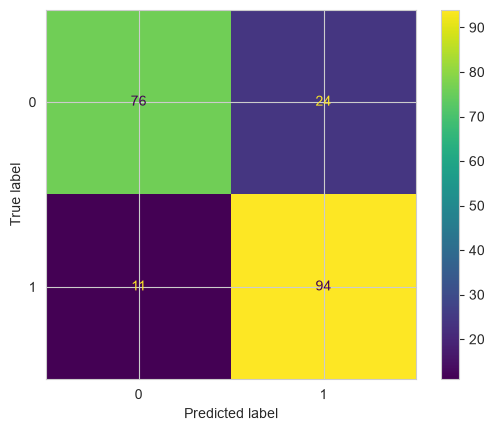

In [24]:
cm = confusion_matrix(
    y_test,
    preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

In [25]:
joblib.dump(
    final_model,
    "../models/heart_disease_model.pkl"
)

print("Model Saved")

Model Saved
